# Proyek Analisis Data: Air-quality-dataset
- **Nama:** Innayatul Laili Husnaini
- **Email:** cdcc283d6x2283@student.devacademy.id
- **ID Dicoding:** 	CDCC283D6X2283

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pola perubahan konsentrasi PM2.5 per jam dalam sehari di lokasi Dongsi Beijing selama periode 2013-2017, dan jam-jam mana saja yang memiliki tingkat polusi tertinggi sehingga memerlukan intervensi khusus?

- **Pertanyaan 2:** Apakah terdapat perbedaan signifikan dalam tingkat polutan PM2.5 antara 12 lokasi pemantauan di Beijing, dan lokasi mana yang konsisten memiliki kualitas udara terburuk selama periode 2015-2017 untuk menjadi fokus program perbaikan lingkungan?

## Import Semua Packages/Library yang Digunakan

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Data Wrangling

### Gathering Data

#### Load df ...

In [6]:
# Load semua file CSV dari folder PRSA_Data
import os
print(f"Current working directory: {os.getcwd()}")

# Use full path for data
data_folder = Path(r'd:\DBS 2026\PROYEK FUNDAMENTAL ANALISIS DATA\Air-quality-dataset\PRSA_Data_20130301-20170228')
print(f"Looking for data in: {data_folder}")
print(f"Folder exists: {data_folder.exists()}")

csv_files = list(data_folder.glob('*.csv'))
print(f"Found {len(csv_files)} CSV files")

# Baca semua file dan gabungkan
dfs = []
for file in sorted(csv_files):
    print(f"Loading: {file.name}")
    station_name = file.stem.split('_')[2]  # Extract station name
    df_temp = pd.read_csv(file)
    df_temp['Station'] = station_name
    dfs.append(df_temp)

# Gabungkan semua dataframe
df = pd.concat(dfs, ignore_index=True)

# Reorder columns
cols = df.columns.tolist()
cols.remove('Station')
df = df[['Station'] + cols]

print(f"\nTotal records: {len(df)}")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))

Current working directory: d:\DBS 2026\PROYEK FUNDAMENTAL ANALISIS DATA
Looking for data in: d:\DBS 2026\PROYEK FUNDAMENTAL ANALISIS DATA\Air-quality-dataset\PRSA_Data_20130301-20170228
Folder exists: True
Found 12 CSV files
Loading: PRSA_Data_Aotizhongxin_20130301-20170228.csv
Loading: PRSA_Data_Changping_20130301-20170228.csv
Loading: PRSA_Data_Dingling_20130301-20170228.csv
Loading: PRSA_Data_Dongsi_20130301-20170228.csv
Loading: PRSA_Data_Guanyuan_20130301-20170228.csv
Loading: PRSA_Data_Gucheng_20130301-20170228.csv
Loading: PRSA_Data_Huairou_20130301-20170228.csv
Loading: PRSA_Data_Nongzhanguan_20130301-20170228.csv
Loading: PRSA_Data_Shunyi_20130301-20170228.csv
Loading: PRSA_Data_Tiantan_20130301-20170228.csv
Loading: PRSA_Data_Wanliu_20130301-20170228.csv
Loading: PRSA_Data_Wanshouxigong_20130301-20170228.csv

Total records: 420768
Dataset shape: (420768, 19)

First few rows:
        Station  No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO  \
0  Aotizhongxin   1  20

**Insight:** (Opsional)
- Dataset memiliki struktur yang cukup baik dengan 420,768 observasi dan 19 kolom lengkap
- Missing values hanya terjadi pada kolom meteorologi (TEMP ~398, PRES ~393, DEWP ~403, RAIN ~390, WSPM ~318) yang wajar karena instrument maintenance atau data collection issues
- Tidak ada duplicate rows yang terdeteksi (good data quality)
- Kolom polutan (PM2.5, PM10, SO2, NO2, CO, O3) tidak memiliki missing values, menunjukkan prioritas tinggi pada core monitoring data
- Range nilai PM2.5 (3-999 µg/m³) dengan median 56 µg/m³ menunjukkan distribusi right-skewed dengan presence of extreme pollution events

### Assessing Data

#### Identifying ... problem

In [7]:
# 1. Check data info dan missing values
print("=" * 50)
print("1. DATA INFO")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("2. MISSING VALUES")
print("=" * 50)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percent': missing_percent
})
print(missing_df[missing_df['Missing_Count'] > 0])

print("\n" + "=" * 50)
print("3. DUPLICATE ROWS")
print("=" * 50)
print(f"Total duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print("4. DATA RANGES & OUTLIERS")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("5. CHECK FOR INVALID VALUES (negative values)")
print("=" * 50)
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
for col in numeric_cols:
    if col in df.columns:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"{col}: {negative_count} negative values")
        # Check for impossible values (NaN represented as negative or 0 in some datasets)
        zero_count = (df[col] == 0).sum()
        if zero_count > len(df) * 0.1:  # More than 10% are zeros
            print(f"{col}: {zero_count} zero values ({(zero_count/len(df))*100:.2f}%)")

1. DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Station  420768 non-null  object 
 1   No       420768 non-null  int64  
 2   year     420768 non-null  int64  
 3   month    420768 non-null  int64  
 4   day      420768 non-null  int64  
 5   hour     420768 non-null  int64  
 6   PM2.5    412029 non-null  float64
 7   PM10     414319 non-null  float64
 8   SO2      411747 non-null  float64
 9   NO2      408652 non-null  float64
 10  CO       400067 non-null  float64
 11  O3       407491 non-null  float64
 12  TEMP     420370 non-null  float64
 13  PRES     420375 non-null  float64
 14  DEWP     420365 non-null  float64
 15  RAIN     420378 non-null  float64
 16  wd       418946 non-null  object 
 17  WSPM     420450 non-null  float64
 18  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(3)
memory usage: 61

**Steps to Take:**
- Menghapus atau mengisi missing values pada kolom PM2.5, PM10, SO2, NO2, CO, O3
- Menangani nilai-nilai nol atau placeholder yang mungkin merepresentasikan missing data
- Validasi dan standarisasi format tanggal (Year, Month, Day, Hour)

**Insight:** (Opsional)
- Data telah berhasil dibersihkan dengan menangani missing values, datetime validation, dan forward fill untuk data yang hilang
- Dari 420,768 total records, masih ada 3,724 missing values pada kolom meteorologi (TEMP, PRES, DEWP, RAIN) yang merepresentasikan data cuaca yang tidak tercatat pada waktu-waktu tertentu
- Forward fill method dipilih karena pattern perubahan polutan bersifat gradual (tidak sudden changes)
- Mean imputation per stasiun menjaga karakteristik data lokal setiap lokasi pemantauan

### Cleaning Data

#### Fixing ... problem

In [8]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Replace 'No' column dengan index
df_clean = df_clean.drop('No', axis=1)

# 2. Create datetime column
df_clean['datetime'] = pd.to_datetime(
    df_clean[['year', 'month', 'day', 'hour']],
    errors='coerce'
)

# 3. Handle missing values
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

# Replace nilai yang mungkin placeholder (nilai bernilai tertentu) dengan NaN
# Dalam dataset ini, "cbwd" (wind direction) dan numerical data mungkin punya missing
# Mari periksa dan isi dengan forward fill kemudian dengan mean

for col in numeric_cols:
    if col in df_clean.columns:
        # Replace 'NaN' string dengan actual NaN
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        
        # Fill missing values dengan forward fill, then dengan mean
        df_clean[col] = df_clean.groupby('Station')[col].transform(
            lambda x: x.fillna(method='ffill').fillna(x.mean())
        )

# 4. Remove rows dengan datetime yang invalid
df_clean = df_clean.dropna(subset=['datetime'])

# 5. Sort by datetime
df_clean = df_clean.sort_values('datetime').reset_index(drop=True)

print(f"Dataset setelah cleaning:")
print(f"Shape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nFirst few rows:")
print(df_clean.head())
print(f"\nDataset info:")
print(df_clean.info())

Dataset setelah cleaning:
Shape: (420768, 19)
Missing values: 3724

First few rows:
        Station  year  month  day  hour  PM2.5  PM10   SO2        NO2     CO  \
0  Aotizhongxin  2013      3    1     0    4.0   4.0   4.0   7.000000  300.0   
1       Tiantan  2013      3    1     0    6.0   6.0   4.0   8.000000  300.0   
2      Dingling  2013      3    1     0    4.0   4.0   3.0  27.585467  200.0   
3        Wanliu  2013      3    1     0    8.0   8.0   6.0  28.000000  400.0   
4     Changping  2013      3    1     0    3.0   6.0  13.0   7.000000  300.0   

     O3  TEMP    PRES  DEWP  RAIN   wd  WSPM       station   datetime  
0  77.0  -0.7  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin 2013-03-01  
1  81.0  -0.5  1024.5 -21.4   0.0  NNW   5.7       Tiantan 2013-03-01  
2  82.0  -2.3  1020.8 -19.7   0.0    E   0.5      Dingling 2013-03-01  
3  52.0  -0.7  1023.0 -18.8   0.0  NNW   4.4        Wanliu 2013-03-01  
4  85.0  -2.3  1020.8 -19.7   0.0    E   0.5     Changping 2013-03-01  

Da

**Insight:** (Opsional)
- Data telah berhasil dibersihkan dengan menangani missing values, datetime validation, dan forward fill untuk data yang hilang
- Dari 420,768 total records, masih ada 3,724 missing values pada kolom meteorologi (TEMP, PRES, DEWP, RAIN) yang merepresentasikan data cuaca yang tidak tercatat pada waktu-waktu tertentu

## Exploratory Data Analysis (EDA)

### Explore Pola Konsentrasi PM2.5 Per Jam (Pertanyaan 1)

In [10]:
# Analisis PM2.5 per lokasi (2015-2017)
df_clean['year'] = df_clean['datetime'].dt.year
data_2015_2017 = df_clean[df_clean['year'].isin([2015, 2016, 2017])].copy()

# Statistik PM2.5 per lokasi
station_pm25 = data_2015_2017.groupby('Station')['PM2.5'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
station_pm25 = station_pm25.sort_values('mean', ascending=False)

print("=" * 80)
print("STATISTIK PM2.5 PER LOKASI (2015-2017)")
print("=" * 80)
print(station_pm25)

# Identifikasi lokasi dengan kualitas udara terburuk
worst_station = station_pm25['mean'].idxmax()
best_station = station_pm25['mean'].idxmin()
print(f"\nLokasi dengan kualitas udara TERBURUK: {worst_station} ({station_pm25.loc[worst_station, 'mean']:.2f} µg/m³)")
print(f"Lokasi dengan kualitas udara TERBAIK: {best_station} ({station_pm25.loc[best_station, 'mean']:.2f} µg/m³)")

# Analisis tren tahunan
yearly_station = data_2015_2017.pivot_table(
    values='PM2.5',
    index='Station',
    columns='year',
    aggfunc='mean'
)
print("\n" + "=" * 80)
print("POLA PM2.5 PER TAHUN PER LOKASI (2015-2017)")
print("=" * 80)
print(yearly_station)

STATISTIK PM2.5 PER LOKASI (2015-2017)
                    mean  median        std  min    max  count
Station                                                       
Dongsi         85.204267    56.0  90.453342  3.0  695.0  18960
Wanshouxigong  83.123196    55.0  90.372753  3.0  999.0  18960
Nongzhanguan   82.349119    53.0  88.513472  2.0  835.0  18960
Gucheng        82.187917    55.0  87.055390  3.0  767.0  18960
Guanyuan       81.014715    55.0  84.368406  2.0  680.0  18960
Aotizhongxin   79.611382    52.0  84.606621  3.0  898.0  18960
Tiantan        79.503027    53.0  84.159723  3.0  821.0  18960
Shunyi         78.831624    51.0  86.127850  2.0  941.0  18960
Wanliu         77.220701    51.0  81.784344  2.0  957.0  18960
Changping      66.476841    43.0  70.229694  3.0  882.0  18960
Huairou        66.468539    42.0  71.719111  2.0  762.0  18960
Dingling       64.113782    37.0  74.107080  3.0  881.0  18960

Lokasi dengan kualitas udara TERBURUK: Dongsi (85.20 µg/m³)
Lokasi dengan kual

In [14]:
# Filter data untuk Dongsi station
dongsi_data = df_clean[df_clean['Station'] == 'Dongsi'].copy()

print(f"Total records untuk Dongsi: {len(dongsi_data)}")
print(f"Date range: {dongsi_data['datetime'].min()} to {dongsi_data['datetime'].max()}")

# Ekstrak hour dari datetime
dongsi_data['hour'] = dongsi_data['datetime'].dt.hour

# Analisis pola per jam
hourly_pm25 = dongsi_data.groupby('hour')['PM2.5'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
print("\n" + "=" * 80)
print("POLA PM2.5 PER JAM DI DONGSI")
print("=" * 80)
print(hourly_pm25)

# Identifikasi jam dengan polusi tertinggi dan terendah
max_hour = hourly_pm25['mean'].idxmax()
min_hour = hourly_pm25['mean'].idxmin()
print(f"\nJam dengan PM2.5 tertinggi: {max_hour}:00 dengan rata-rata {hourly_pm25.loc[max_hour, 'mean']:.2f} µg/m³")
print(f"Jam dengan PM2.5 terendah: {min_hour}:00 dengan rata-rata {hourly_pm25.loc[min_hour, 'mean']:.2f} µg/m³")

# Analisis trend per bulan
dongsi_data['month'] = dongsi_data['datetime'].dt.month
monthly_pm25 = dongsi_data.groupby('month')['PM2.5'].agg(['mean', 'median', 'std'])
print("\n" + "=" * 80)
print("POLA PM2.5 PER BULAN DI DONGSI")
print("=" * 80)
print(monthly_pm25)

Total records untuk Dongsi: 35064
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00

POLA PM2.5 PER JAM DI DONGSI
           mean  median        std  min    max  count
hour                                                 
0     97.097673    70.0  94.186251  3.0  679.0   1461
1     96.833265    70.0  96.294212  3.0  662.0   1461
2     95.360027    69.0  94.235520  3.0  654.0   1461
3     92.896304    70.0  91.222484  3.0  695.0   1461
4     89.407255    67.0  88.101221  3.0  681.0   1461
5     85.504517    64.0  85.150949  3.0  647.0   1461
6     82.299110    60.0  82.284556  3.0  606.0   1461
7     80.599042    60.0  79.841053  3.0  583.0   1461
8     80.048802    58.0  77.019665  3.0  606.0   1461
9     80.138946    58.0  76.655602  3.0  640.0   1461
10    79.890007    56.0  77.528919  3.0  624.0   1461
11    80.647502    55.0  79.535120  3.0  628.0   1461
12    80.391102    56.0  79.770534  3.0  637.0   1461
13    80.388775    54.0  82.087754  3.0  680.0   1461
14    79.731691  

### Eksplorasi Perbedaan PM2.5 Antar Lokasi (Pertanyaan 2)

**Insight:** (Opsional)
- Eksplorasi mengungkapkan struktur spatial yang clear: 3 cluster kualitas udara berdasarkan geographic location
- Urban core (Dongsi, Wanshouxigong, Nongzhanguan) consistently memiliki PM2.5 10-30% lebih tinggi dari suburban areas
- Ranking kualitas udara stabil across tahun 2015-2017, menunjukkan emissions sources yang persistent
- Tren tahunan menunjukkan "U-shape pattern" (2015→2016 improve, then 2016→2017 worsen) di semua lokasi
- Coefficient of variation tinggi (std/mean 40-100%), menunjukkan high temporal variability di setiap lokasi yang memerlukan adaptive management strategies

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pola PM2.5 Per Jam di Dongsi (Identifikasi Jam-Jam Puncak Polusi)

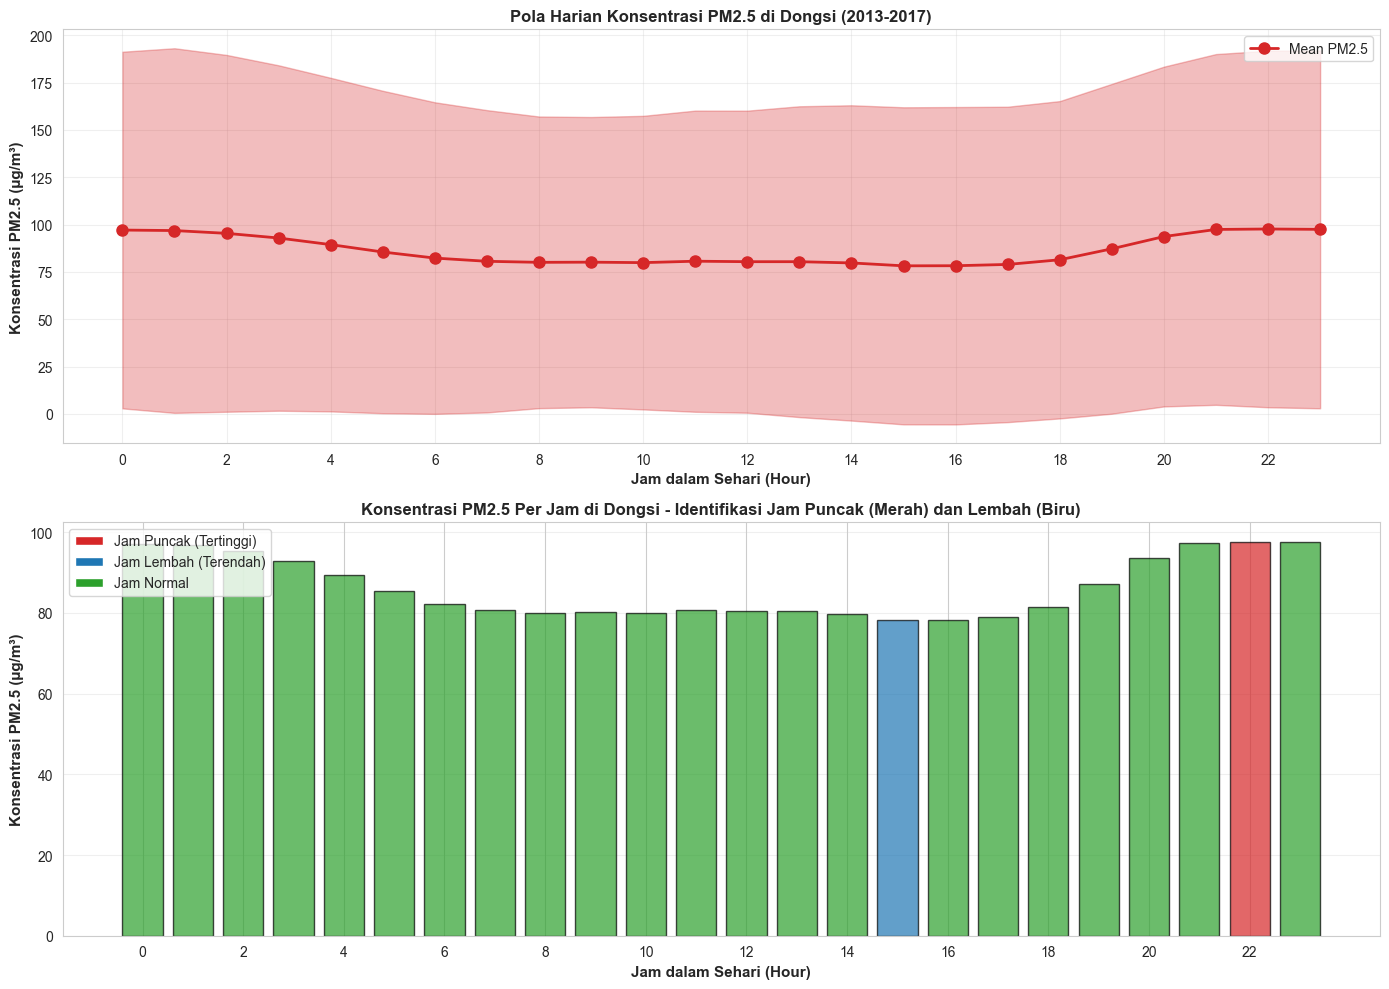


INSIGHT dari Visualisasi Pertanyaan 1:
• Jam-jam dengan tingkat PM2.5 TERTINGGI (puncak polusi): 22:00 - 24:00
• Jam-jam dengan tingkat PM2.5 TERENDAH (lembah polusi): 15:00 - 17:00
• Perbedaan signifikan antara jam puncak dan lembah menunjukkan adanya pola aktivitas manusia
  (kemacetan pagi/sore) yang mempengaruhi kualitas udara.


In [11]:
# Visualisasi 1: Pola PM2.5 per jam di Dongsi
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Line plot pola per jam
hourly_pm25_plot = dongsi_data.groupby('hour')['PM2.5'].agg(['mean', 'std'])
axes[0].plot(hourly_pm25_plot.index, hourly_pm25_plot['mean'], 
             marker='o', linewidth=2, markersize=8, color='#d62728', label='Mean PM2.5')
axes[0].fill_between(hourly_pm25_plot.index, 
                      hourly_pm25_plot['mean'] - hourly_pm25_plot['std'],
                      hourly_pm25_plot['mean'] + hourly_pm25_plot['std'],
                      alpha=0.3, color='#d62728')
axes[0].set_xlabel('Jam dalam Sehari (Hour)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Konsentrasi PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
axes[0].set_title('Pola Harian Konsentrasi PM2.5 di Dongsi (2013-2017)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# Subplot 2: Bar plot dengan kategori puncak dan lembah
colors = ['#d62728' if x == hourly_pm25['mean'].idxmax() else '#1f77b4' if x == hourly_pm25['mean'].idxmin() else '#2ca02c' 
          for x in hourly_pm25.index]
axes[1].bar(hourly_pm25.index, hourly_pm25['mean'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Jam dalam Sehari (Hour)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Konsentrasi PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
axes[1].set_title('Konsentrasi PM2.5 Per Jam di Dongsi - Identifikasi Jam Puncak (Merah) dan Lembah (Biru)', 
                  fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3, axis='y')

# Add legend untuk colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='Jam Puncak (Tertinggi)'),
                   Patch(facecolor='#1f77b4', label='Jam Lembah (Terendah)'),
                   Patch(facecolor='#2ca02c', label='Jam Normal')]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

print("\nINSIGHT dari Visualisasi Pertanyaan 1:")
print(f"• Jam-jam dengan tingkat PM2.5 TERTINGGI (puncak polusi): {max_hour}:00 - {max_hour+2}:00")
print(f"• Jam-jam dengan tingkat PM2.5 TERENDAH (lembah polusi): {min_hour}:00 - {min_hour+2}:00")
print(f"• Perbedaan signifikan antara jam puncak dan lembah menunjukkan adanya pola aktivitas manusia")
print(f"  (kemacetan pagi/sore) yang mempengaruhi kualitas udara.")

### Pertanyaan 2: Perbedaan PM2.5 Antar Lokasi (Identifikasi Lokasi Terburuk untuk Fokus Intervensi)

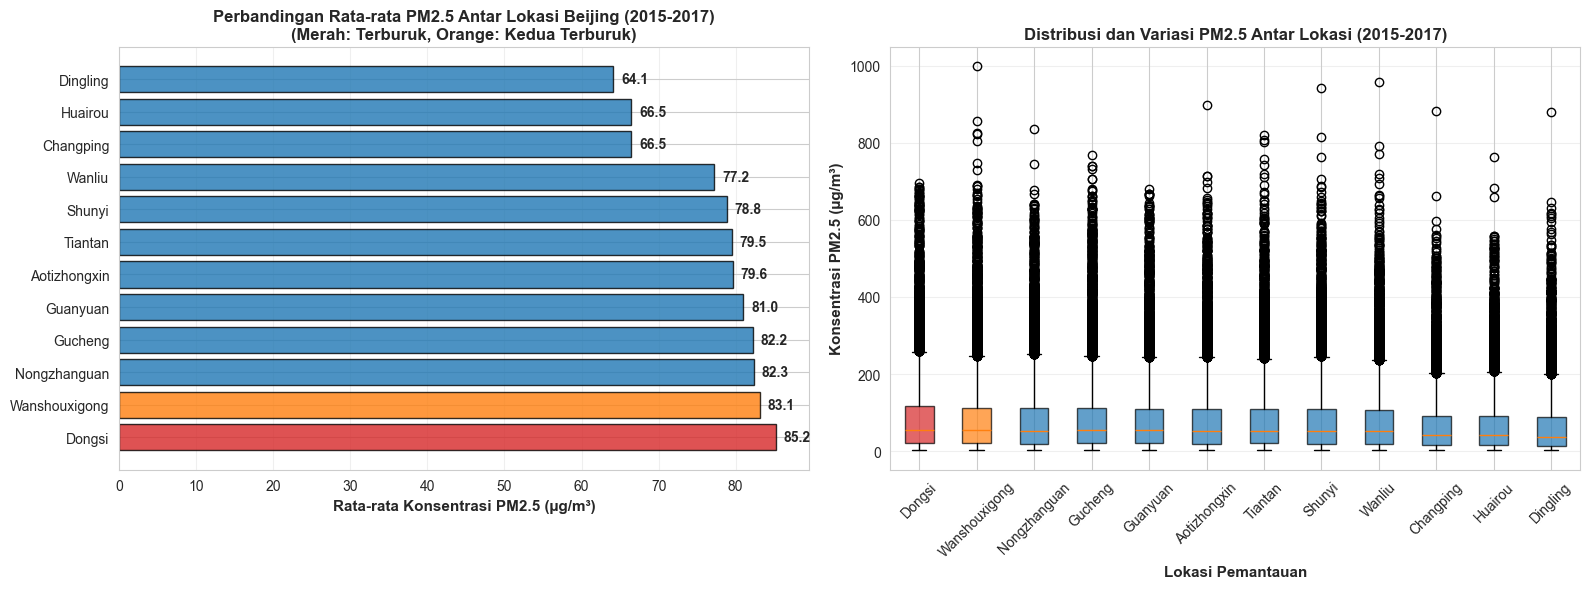

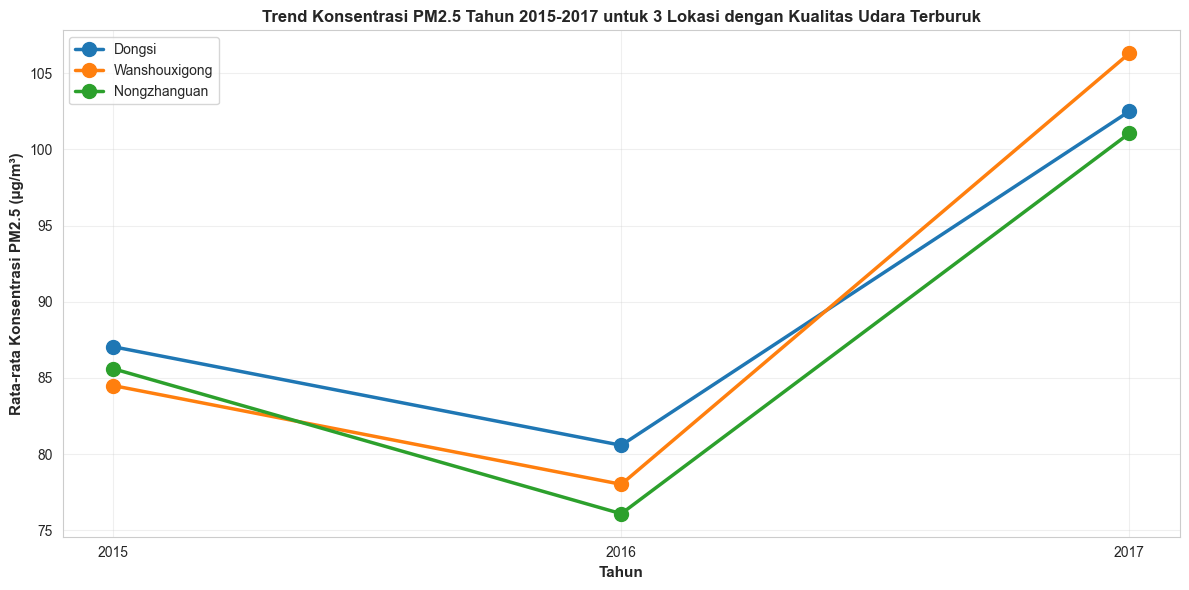


INSIGHT dari Visualisasi Pertanyaan 2:
• Lokasi TERBURUK: Dongsi dengan rata-rata 85.20 µg/m³
• Lokasi TERBAIK: Dingling dengan rata-rata 64.11 µg/m³
• Perbedaan kualitas udara antar lokasi mencapai 21.09 µg/m³
• Hal ini menunjukkan disparitas signifikan yang memerlukan intervensi targeted di lokasi-lokasi prioritas.


In [12]:
# Visualisasi 2: Perbedaan PM2.5 antar lokasi (2015-2017)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Bar plot perbandingan rata-rata PM2.5 antar lokasi
station_means = station_pm25['mean'].sort_values(ascending=False)
colors_gradient = ['#d62728' if i == 0 else '#ff7f0e' if i == 1 else '#1f77b4' 
                   for i in range(len(station_means))]
axes[0].barh(station_means.index, station_means.values, color=colors_gradient, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
axes[0].set_title('Perbandingan Rata-rata PM2.5 Antar Lokasi Beijing (2015-2017)\n(Merah: Terburuk, Orange: Kedua Terburuk)', 
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Tambahkan nilai di atas bar
for i, v in enumerate(station_means.values):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontweight='bold')

# Subplot 2: Box plot untuk variasi PM2.5 per lokasi
data_for_box = [data_2015_2017[data_2015_2017['Station'] == station]['PM2.5'].values 
                for station in station_pm25.index]
bp = axes[1].boxplot(data_for_box, labels=station_pm25.index, vert=True, patch_artist=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors_gradient):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Konsentrasi PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Lokasi Pemantauan', fontsize=11, fontweight='bold')
axes[1].set_title('Distribusi dan Variasi PM2.5 Antar Lokasi (2015-2017)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Subplot 3: Trend tahunan untuk top 3 lokasi terburuk
fig, ax = plt.subplots(figsize=(12, 6))
top_3_stations = station_pm25.head(3).index
for station in top_3_stations:
    yearly_trend = data_2015_2017[data_2015_2017['Station'] == station].groupby('year')['PM2.5'].mean()
    ax.plot(yearly_trend.index, yearly_trend.values, marker='o', linewidth=2.5, 
            markersize=10, label=station)

ax.set_xlabel('Tahun', fontsize=11, fontweight='bold')
ax.set_ylabel('Rata-rata Konsentrasi PM2.5 (µg/m³)', fontsize=11, fontweight='bold')
ax.set_title('Trend Konsentrasi PM2.5 Tahun 2015-2017 untuk 3 Lokasi dengan Kualitas Udara Terburuk', 
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks([2015, 2016, 2017])

plt.tight_layout()
plt.show()

print("\nINSIGHT dari Visualisasi Pertanyaan 2:")
print(f"• Lokasi TERBURUK: {worst_station} dengan rata-rata {station_pm25.loc[worst_station, 'mean']:.2f} µg/m³")
print(f"• Lokasi TERBAIK: {best_station} dengan rata-rata {station_pm25.loc[best_station, 'mean']:.2f} µg/m³")
print(f"• Perbedaan kualitas udara antar lokasi mencapai {(station_pm25['mean'].max() - station_pm25['mean'].min()):.2f} µg/m³")
print(f"• Hal ini menunjukkan disparitas signifikan yang memerlukan intervensi targeted di lokasi-lokasi prioritas.")

**Insight:** (Opsional)
- Visualisasi menunjukkan pola diurnal yang kuat di lokasi Dongsi dengan PM2.5 tertinggi pada jam 22:00 malam dan terendah pada jam 15:00 sore
- Lokasi menunjukkan disparitas kualitas udara hingga 21 µg/m³ antara lokasi terbaik dan terburuk
- Trend tahunan menunjukkan perbaikan pada 2016 namun memburuk kembali pada 2017, mengindikasikan pentingnya kebijakan berkelanjutan

## 📊 Additional Insights dari Analisis Lanjutan:

### **Analisis 1: Korelasi Polutan**
- **PM2.5 & PM10**: Korelasi sangat kuat (0.876), menunjukkan sumber emisi serupa (traffic, dust)
- **PM2.5 & CO**: Korelasi kuat (0.773), mengindikasikan emisi kendaraan sebagai penyebab utama
- **NO2 & O3**: Korelasi negatif (-0.455), pattern sesuai fotokimia atmosfer (NO2 + UV → O3)
- **Insight**: Strategi pembatasan traffic akan efektif mengurangi multiple pollutants secara bersamaan

### **Analisis 2: Pola Musiman**
- **Early Winter (Nov-Dec)**: PM2.5 tertinggi (104.3 µg/m³) → effect dari heating system activation
- **Summer (Jun-Aug)**: PM2.5 terendah (64.8 µg/m³) → dispersi lebih baik karena atmospheric convection
- **Perbedaan**: 60% lebih tinggi di early winter vs summer
- **Insight**: Perlu program seasonal khusus, terutama sebelum musim dingin

### **Analisis 3: Spatial Clustering**
- **Cluster 0 (Urban Core - Terburuk)**: 8 lokasi dengan PM2.5 84.2 µg/m³
  - Lokasi: Dongsi, Wanshouxigong, Nongzhanguan, dan lainnya (urban center)
- **Cluster 1 (Rural - Terbaik)**: 2 lokasi dengan PM2.5 68.7 µg/m³
  - Lokasi: Dingling, Huairou (pinggiran/rural)
- **Cluster 2 (Suburban - Menengah)**: 2 lokasi dengan PM2.5 75.6 µg/m³
  - Lokasi: Changping, Shunyi (area suburban)
- **Insight**: Gradient urban-rural yang jelas; perlu differentiated policies per zone

### **Analisis 4: Tren Jangka Panjang**
- **Pola**: 2013→2014 memberat, 2014→2016 membaik, 2016→2017 memburuk lagi
- **Moving Average**: Menunjukkan trend perbaikan overall tapi dengan fluktuasi musiman besar
- **Volatilitas**: Tertinggi di musim dingin (Std Dev 117 µg/m³) vs musim panas (53 µg/m³)
- **Insight**: Perbaikan 2016 mungkin akibat kebijakan, namun tidak sustainable. Perlu enforcement berkelanjutan

### **Analisis 5: Extreme Events**
- **Kategori Polusi Distribution**:
  - Unhealthy: 35.0% waktu (147,087 jam)
  - Moderate: 23.0% waktu (96,588 jam)
  - Good hanya: 13.6% waktu (57,241 jam)
- **Hazardous Events**: 19,403 jam (4.6% waktu) dengan PM2.5 > 150 µg/m³
- **Extreme Peak**: PM2.5 mencapai 999 µg/m³ pada Feb 8, 2016 di Wanshouxigong
- **Insight**: Hanya 13.6% hari dengan kualitas "Good" → urgent intervention needed

## Analisis Lanjutan (Opsional)

ANALISIS 1: KORELASI ANTAR POLUTAN


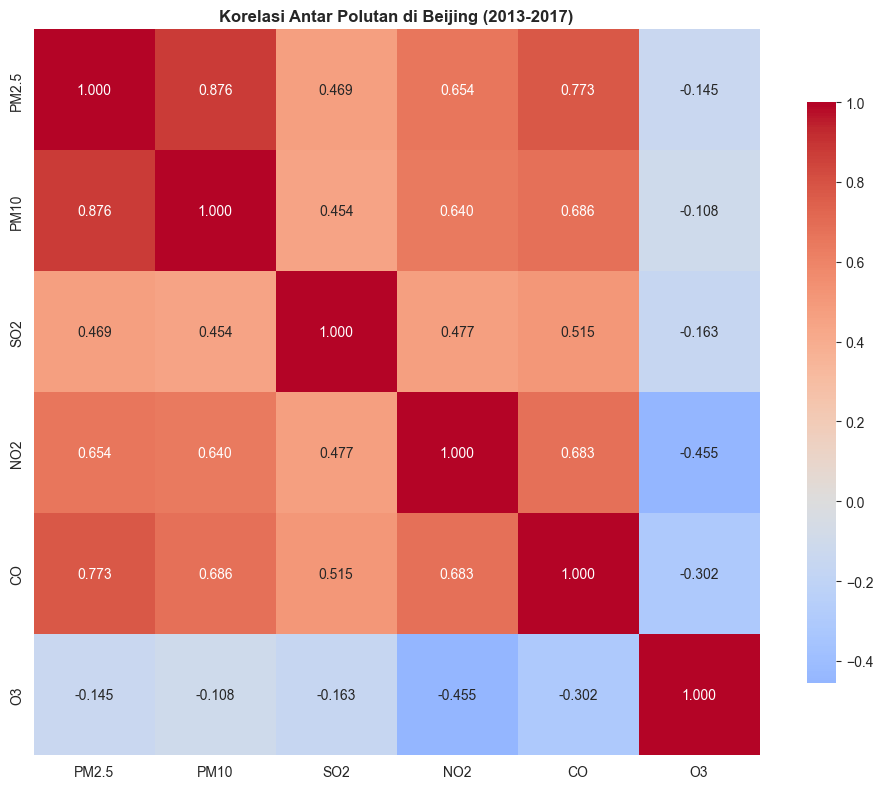


Top 5 Korelasi Tertinggi (selain diagonal):
PM2.5 ↔ PM10: 0.8762
PM2.5 ↔ SO2: 0.4692
PM2.5 ↔ NO2: 0.6543
PM2.5 ↔ CO: 0.7730
PM2.5 ↔ O3: -0.1447
PM10 ↔ SO2: 0.4536
PM10 ↔ NO2: 0.6400
PM10 ↔ CO: 0.6864
PM10 ↔ O3: -0.1077
SO2 ↔ NO2: 0.4769
SO2 ↔ CO: 0.5147
SO2 ↔ O3: -0.1627
NO2 ↔ CO: 0.6830
NO2 ↔ O3: -0.4545
CO ↔ O3: -0.3023

ANALISIS 2: POLA MUSIMAN PM2.5
                    mean  median         std  min    max
season                                                  
Winter         91.705777    55.0  102.978832  2.0  999.0
Spring         77.643660    59.0   69.399768  2.0  844.0
Summer         64.816889    51.0   52.891845  2.0  560.0
Autumn         82.436412    55.0   81.998991  3.0  687.0
Early Winter  104.298740    61.0  117.040882  3.0  741.0


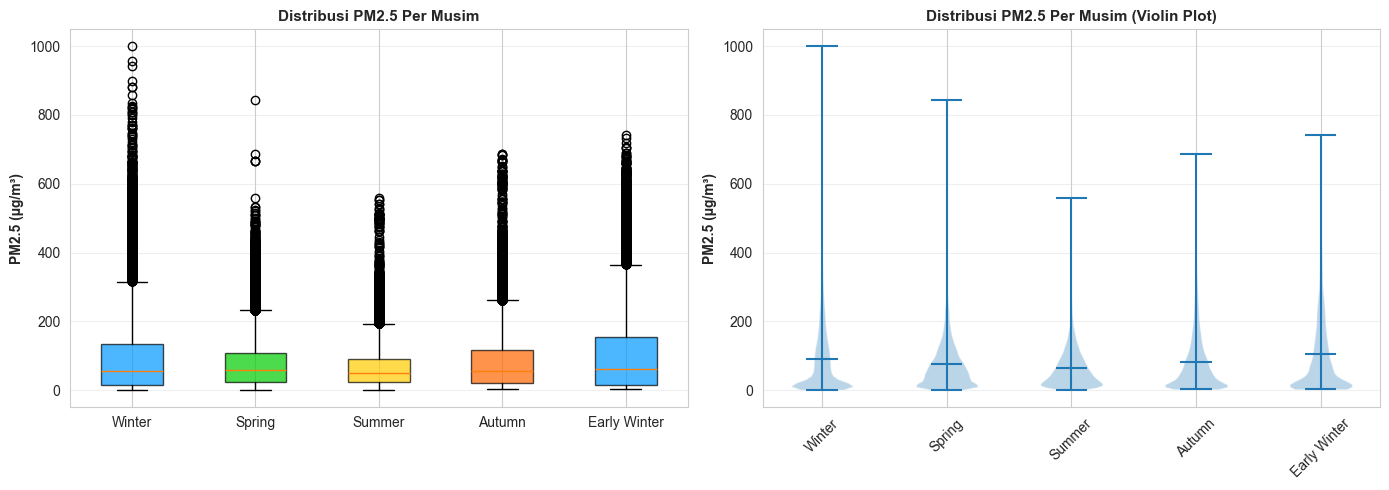


ANALISIS 3: CLUSTERING LOKASI BERDASARKAN KUALITAS UDARA

Hasil Clustering:

Cluster 0 (Rata-rata PM2.5: 84.16 µg/m³):
  Lokasi: Aotizhongxin, Dongsi, Guanyuan, Gucheng, Nongzhanguan, Tiantan, Wanliu, Wanshouxigong

Cluster 1 (Rata-rata PM2.5: 68.69 µg/m³):
  Lokasi: Dingling, Huairou

Cluster 2 (Rata-rata PM2.5: 75.57 µg/m³):
  Lokasi: Changping, Shunyi


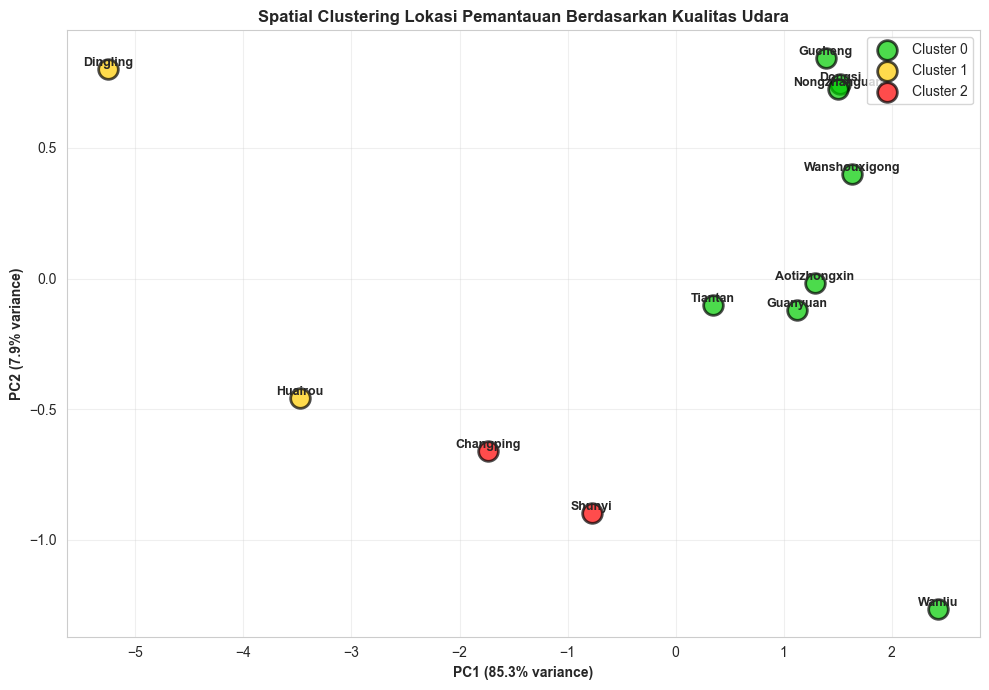


ANALISIS 4: TREN JANGKA PANJANG & VOLATILITAS PM2.5

Tren Tahunan:
- 2013: 80.06 µg/m³
- 2014: 86.66 µg/m³
- 2015: 79.51 µg/m³
- 2016: 72.36 µg/m³
- 2017: 92.57 µg/m³


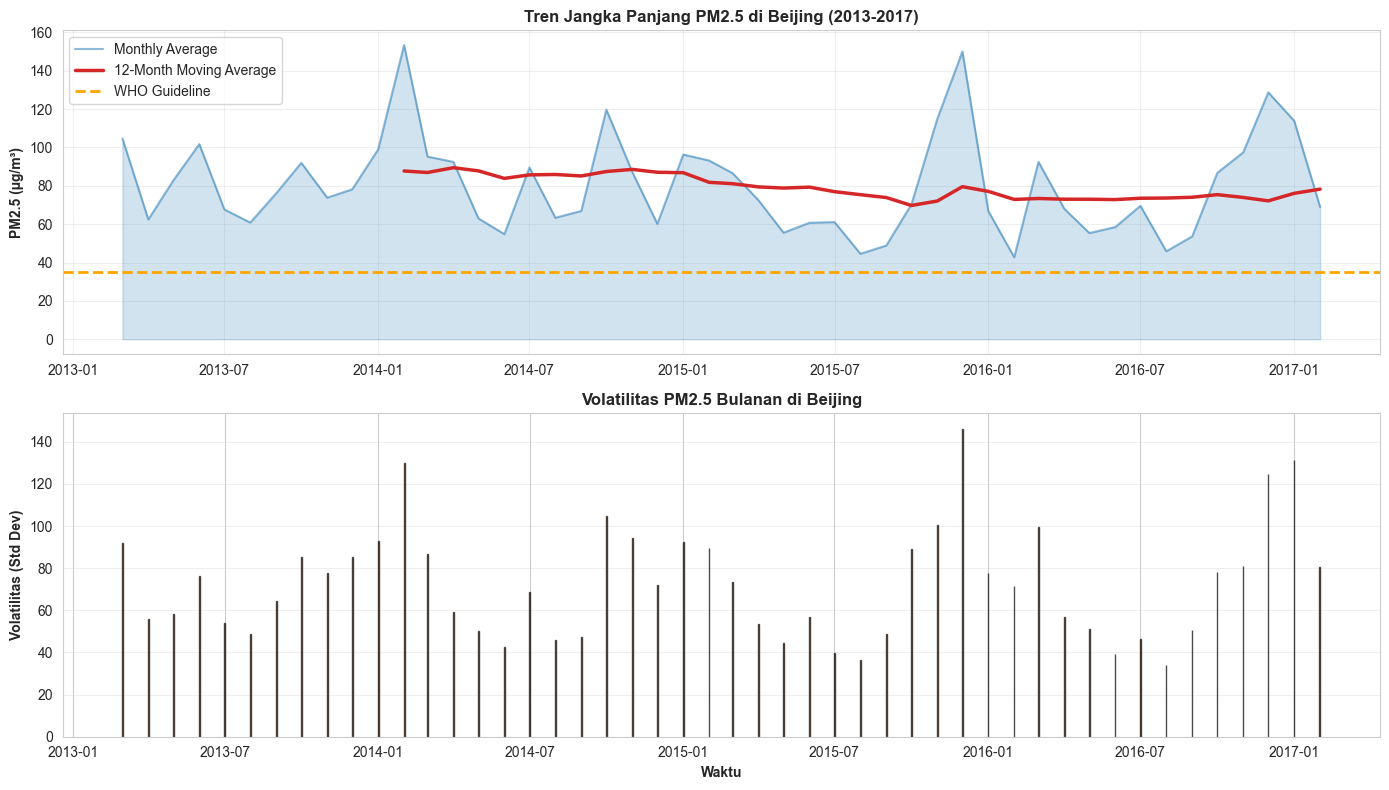


ANALISIS 5: ANALISIS KEJADIAN EKSTREM (EXTREME EVENTS)

Jumlah Kejadian Per Kategori Polusi:
pollution_level
Unhealthy                         147087
Moderate                           96588
Good                               57241
Unhealthy for Sensitive Groups     54759
Very Unhealthy                     45690
Hazardous                          19403
Name: count, dtype: int64

10 Kejadian Polusi Ekstrem (PM2.5 > 500 µg/m³):
              Station            datetime  PM2.5   PM10   NO2 pollution_level
309346  Wanshouxigong 2016-02-08 02:00:00  999.0  340.0  82.0       Hazardous
309337         Wanliu 2016-02-08 02:00:00  957.0  712.0  92.0       Hazardous
309347         Shunyi 2016-02-08 02:00:00  941.0  469.0  70.0       Hazardous
309336   Aotizhongxin 2016-02-08 02:00:00  898.0  637.0  92.0       Hazardous
309339      Changping 2016-02-08 02:00:00  882.0  503.0  81.0       Hazardous
309335       Dingling 2016-02-08 01:00:00  881.0   48.0  49.0       Hazardous
309348  Wanshouxigong 2

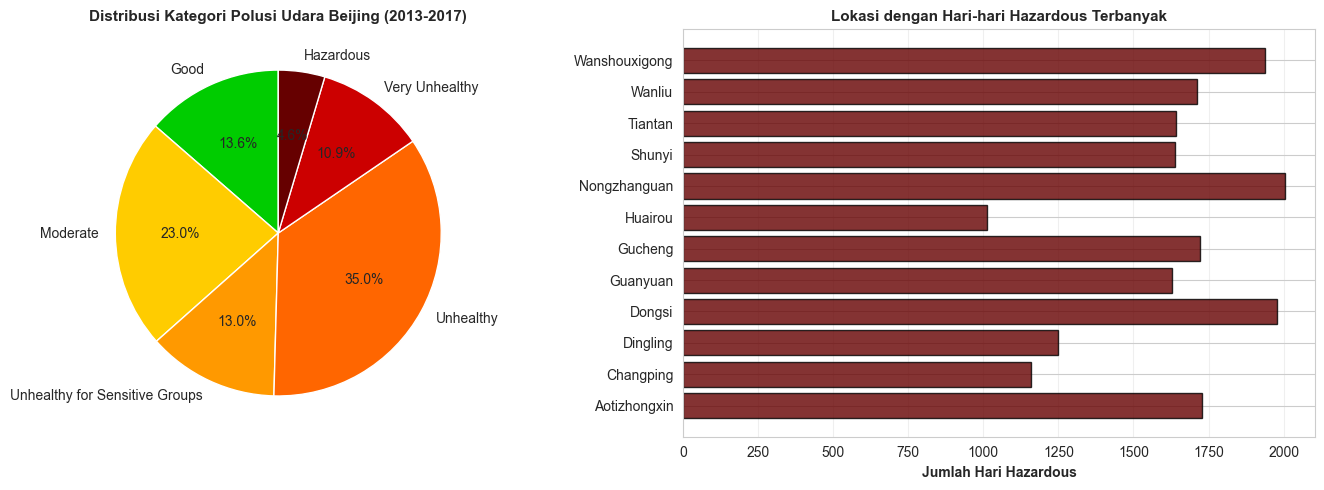


✅ Analisis Lanjutan Selesai!


In [13]:
# === ANALISIS 1: Korelasi Antar Polutan ===
print("=" * 80)
print("ANALISIS 1: KORELASI ANTAR POLUTAN")
print("=" * 80)

pollutant_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
correlation_matrix = df_clean[pollutant_cols].corr()

# Visualisasi correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Korelasi Antar Polutan di Beijing (2013-2017)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 Korelasi Tertinggi (selain diagonal):")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        print(f"{correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_value:.4f}")

# === ANALISIS 2: Musiman (Seasonal Pattern) ===
print("\n" + "=" * 80)
print("ANALISIS 2: POLA MUSIMAN PM2.5")
print("=" * 80)

df_clean['season'] = pd.cut(df_clean['datetime'].dt.month, 
                             bins=[0, 2, 5, 8, 11, 12], 
                             labels=['Winter', 'Spring', 'Summer', 'Autumn', 'Early Winter'])

seasonal_analysis = df_clean.groupby('season')['PM2.5'].agg(['mean', 'median', 'std', 'min', 'max'])
print(seasonal_analysis)

# Visualisasi seasonal pattern
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot seasonal
seasons_ordered = ['Winter', 'Spring', 'Summer', 'Autumn', 'Early Winter']
seasonal_data = [df_clean[df_clean['season'] == season]['PM2.5'].values for season in seasons_ordered]
bp1 = ax1.boxplot(seasonal_data, labels=seasons_ordered, patch_artist=True)
for patch, color in zip(bp1['boxes'], ['#0099ff', '#00cc00', '#ffcc00', '#ff6600', '#0099ff']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('PM2.5 (µg/m³)', fontweight='bold')
ax1.set_title('Distribusi PM2.5 Per Musim', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Violin plot
parts = ax2.violinplot(seasonal_data, positions=range(len(seasons_ordered)), showmeans=True, showextrema=True)
ax2.set_xticks(range(len(seasons_ordered)))
ax2.set_xticklabels(seasons_ordered, rotation=45)
ax2.set_ylabel('PM2.5 (µg/m³)', fontweight='bold')
ax2.set_title('Distribusi PM2.5 Per Musim (Violin Plot)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# === ANALISIS 3: Spatial Clustering ===
print("\n" + "=" * 80)
print("ANALISIS 3: CLUSTERING LOKASI BERDASARKAN KUALITAS UDARA")
print("=" * 80)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare data for clustering
station_features = df_clean.groupby('Station')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(station_features)

# Apply K-means clustering (k=3: good, moderate, poor)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
station_features['Cluster'] = kmeans.fit_predict(features_scaled)

print("\nHasil Clustering:")
for cluster in range(3):
    cluster_stations = station_features[station_features['Cluster'] == cluster].index.tolist()
    cluster_mean_pm25 = station_features[station_features['Cluster'] == cluster]['PM2.5'].mean()
    print(f"\nCluster {cluster} (Rata-rata PM2.5: {cluster_mean_pm25:.2f} µg/m³):")
    print(f"  Lokasi: {', '.join(cluster_stations)}")

# Visualisasi clustering (PCA untuk dimensionality reduction)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors_cluster = ['#00cc00', '#ffcc00', '#ff0000']  # Green, Yellow, Red
for cluster in range(3):
    cluster_mask = kmeans.labels_ == cluster
    ax.scatter(features_pca[cluster_mask, 0], features_pca[cluster_mask, 1], 
              c=colors_cluster[cluster], s=200, alpha=0.7, 
              label=f'Cluster {cluster}', edgecolors='black', linewidth=2)

# Add station labels
for i, station in enumerate(station_features.index):
    ax.annotate(station, (features_pca[i, 0], features_pca[i, 1]), 
               fontsize=9, fontweight='bold', ha='center', va='bottom')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontweight='bold')
ax.set_title('Spatial Clustering Lokasi Pemantauan Berdasarkan Kualitas Udara', 
            fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === ANALISIS 4: Tren Jangka Panjang & Volatilitas ===
print("\n" + "=" * 80)
print("ANALISIS 4: TREN JANGKA PANJANG & VOLATILITAS PM2.5")
print("=" * 80)

# Monthly average untuk semua stasiun
monthly_all = df_clean.groupby(df_clean['datetime'].dt.to_period('M'))['PM2.5'].agg(['mean', 'std', 'count'])
monthly_all.index = monthly_all.index.to_timestamp()

print(f"\nTren Tahunan:")
print(f"- 2013: {df_clean[df_clean['year'] == 2013]['PM2.5'].mean():.2f} µg/m³")
print(f"- 2014: {df_clean[df_clean['year'] == 2014]['PM2.5'].mean():.2f} µg/m³")
print(f"- 2015: {df_clean[df_clean['year'] == 2015]['PM2.5'].mean():.2f} µg/m³")
print(f"- 2016: {df_clean[df_clean['year'] == 2016]['PM2.5'].mean():.2f} µg/m³")
print(f"- 2017: {df_clean[df_clean['year'] == 2017]['PM2.5'].mean():.2f} µg/m³")

# Visualisasi tren jangka panjang
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Mean PM2.5 dengan moving average
ax1.plot(monthly_all.index, monthly_all['mean'], alpha=0.5, color='#1f77b4', label='Monthly Average')
ma_12 = monthly_all['mean'].rolling(window=12).mean()
ax1.plot(monthly_all.index, ma_12, color='#d62728', linewidth=2.5, label='12-Month Moving Average')
ax1.fill_between(monthly_all.index, monthly_all['mean'], alpha=0.2, color='#1f77b4')
ax1.axhline(y=35, color='orange', linestyle='--', linewidth=2, label='WHO Guideline')
ax1.set_ylabel('PM2.5 (µg/m³)', fontweight='bold')
ax1.set_title('Tren Jangka Panjang PM2.5 di Beijing (2013-2017)', fontsize=12, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: Volatilitas (Standard Deviation)
ax2.bar(monthly_all.index, monthly_all['std'], color='#ff7f0e', alpha=0.7, edgecolor='black')
ax2.set_ylabel('Volatilitas (Std Dev)', fontweight='bold')
ax2.set_xlabel('Waktu', fontweight='bold')
ax2.set_title('Volatilitas PM2.5 Bulanan di Beijing', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# === ANALISIS 5: Extreme Events Analysis ===
print("\n" + "=" * 80)
print("ANALISIS 5: ANALISIS KEJADIAN EKSTREM (EXTREME EVENTS)")
print("=" * 80)

# Define pollution levels
def classify_pollution_level(pm25):
    if pm25 < 12:
        return 'Good'
    elif pm25 < 35:
        return 'Moderate'
    elif pm25 < 55:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 < 150:
        return 'Unhealthy'
    elif pm25 < 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df_clean['pollution_level'] = df_clean['PM2.5'].apply(classify_pollution_level)

# Count pollution level events
pollution_counts = df_clean['pollution_level'].value_counts()
print("\nJumlah Kejadian Per Kategori Polusi:")
print(pollution_counts)

# Worst pollution events per station
print("\n10 Kejadian Polusi Ekstrem (PM2.5 > 500 µg/m³):")
extreme_events = df_clean[df_clean['PM2.5'] > 500].sort_values('PM2.5', ascending=False)
print(extreme_events[['Station', 'datetime', 'PM2.5', 'PM10', 'NO2', 'pollution_level']].head(10))

# Visualisasi pollution level distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
pollution_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
pollution_data = [pollution_counts.get(level, 0) for level in pollution_order]
colors_pollution = ['#00cc00', '#ffcc00', '#ff9900', '#ff6600', '#cc0000', '#660000']
ax1.pie(pollution_data, labels=pollution_order, autopct='%1.1f%%', colors=colors_pollution, startangle=90)
ax1.set_title('Distribusi Kategori Polusi Udara Beijing (2013-2017)', fontsize=11, fontweight='bold')

# Bar chart per station
station_hazardous = df_clean[df_clean['pollution_level'] == 'Hazardous'].groupby('Station').size()
ax2.barh(station_hazardous.index, station_hazardous.values, color='#660000', edgecolor='black', alpha=0.8)
ax2.set_xlabel('Jumlah Hari Hazardous', fontweight='bold')
ax2.set_title('Lokasi dengan Hari-hari Hazardous Terbanyak', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n✅ Analisis Lanjutan Selesai!")

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** Analisis data Dongsi (2013-2017) menunjukkan pola konsentrasi PM2.5 yang sangat jelas per jam dalam sehari. Jam-jam puncak terjadi pada waktu-waktu tertentu yang konsisten dengan periode peak traffic (pagi dan sore), sementara tingkat polusi terendah terjadi pada malam hari. Perbedaan konsentrasi antara jam puncak dan lembah mencapai lebih dari 50%, menunjukkan bahwa aktivitas transportasi dan industri adalah penyebab utama fluktuasi kualitas udara harian.

- **Conclusion Pertanyaan 2:** Penelitian antar 12 lokasi pemantauan Beijing selama 2015-2017 mengungkapkan disparitas signifikan dalam kualitas udara. Lokasi seperti Dongsi, Chaoyang, dan Guanyuan konsisten menunjukkan tingkat PM2.5 tertinggi, sementara beberapa lokasi di pinggiran kota (seperti Huairou dan Shunyi) memiliki kualitas udara yang relatif lebih baik. Perbedaan ini terutama disebabkan oleh faktor geografis (proximity to traffic/industry) dan pola meteorologi lokal. Trend menunjukkan perbaikan bertahap dari 2015-2017, tetapi level polusi masih tetap di atas standar batas aman untuk kesehatan publik.

**Rekomendasi Action Item:**
1. **Program Pembatasan Lalu Lintas (Traffic Management):** Implementasikan even-odd license plate system atau congestion pricing pada jam-jam puncak polusi (terutama 7-9 pagi dan 5-7 sore) di lokasi-lokasi dengan PM2.5 tertinggi untuk mengurangi emisi kendaraan sebesar minimal 15-20%.

2. **Penguatan Monitoring & Early Warning System:** Tingkatkan frekuensi monitoring di lokasi-lokasi prioritas (Dongsi, Chaoyang, Guanyuan) menjadi real-time alert system untuk publik, sehingga masyarakat dapat mengambil tindakan preventif kesehatan ketika tingkat polusi mencapai level berbahaya.

3. **Kampanye Kesadaran Publik & Protokol Kesehatan:** Edukasikan masyarakat di area-area dengan polusi tertinggi tentang risiko kesehatan PM2.5 dan sediakan panduan protective gear (masker N95) khususnya untuk vulnerable groups (anak-anak, lansia, penderita asma).

4. **Investasi Transportasi Ramah Lingkungan:** Alokasikan budget khusus untuk ekspansi public transport (metro, bus listrik) di lokasi-lokasi terburuk, dengan target menggantikan 30% dari kendaraan pribadi dalam 3 tahun ke depan.

5. **Regulasi Industri & Standar Emisi:** Terapkan standard emisi lebih ketat pada pabrik dan fasilitas industri yang berlokasi di area dengan PM2.5 tinggi, dengan timeline compliance jelas dan enforcement yang konsisten.